# EDA: ConversaAI — Sentiment & Intent Analysis

**Proposito:** Analisis exploratorio del dataset preprocesado de conversaciones de soporte.

- Dataset: `data/processed/data_preprocessed.csv`
- Filas: 20,001 | Columnas: 15

## 1. IMPORTS Y CONFIGURACION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
sns.set_palette('Set2')

# Rutas
DATA_PATH = Path('../data/processed/data_preprocessed.csv')
REPORTS_PATH = Path('../reports/')
REPORTS_PATH.mkdir(exist_ok=True)
FIGURES_PATH = Path('../reports/figures/')
FIGURES_PATH.mkdir(exist_ok=True)

## 2. CARGA DE DATOS

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

Dimensiones: 20001 filas x 15 columnas
Memoria: 14.08 MB


In [3]:
# Vista rapida
df.head(3)

,session_id,turn_number,flow_name,usuario,fecha,intencion,nivel_frustracion,texto_espanol,texto_portugues,es_churn_risk,resolved,idioma,texto_original,texto_clean,texto_vacio
0,SESS-447996,1,Facturación y Cobros,@soyMarely89,2026-01-04 16:50:00,problema_pago,0,Tengo un problema con un cobro.,Tenho um problema com uma cobrança.,0,0,es,Tengo un problema con un cobro.,tengo un problema con un cobro,False
1,SESS-447996,2,Facturación y Cobros,@soyMarely89,2026-01-04 16:55:00,problema_pago,1,Nadie me ayuda con el cobro doble.,Ninguém me ajuda com a cobrança dupla.,0,0,es,Nadie me ayuda con el cobro doble.,nadie me ayuda con el cobro doble,False
2,SESS-447996,3,Facturación y Cobros,@soyMarely89,2026-01-04 17:00:00,problema_pago,0,Tengo un problema con un cobro.,Tenho um problema com uma cobrança.,0,1,es,Tengo un problema con un cobro.,tengo un problema con un cobro,False


In [4]:
# Tipos de datos
dtype_info = pd.DataFrame({
    'Tipo': df.dtypes,
    'No Nulos': df.count(),
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df)) * 100,
    'Cardinalidad': df.nunique(),
    'Duplicados': [df.duplicated(subset=[c]).sum() for c in df.columns]
})
dtype_info

,Tipo,No Nulos,Nulos,% Nulos,Cardinalidad,Duplicados
session_id,str,20001,0,0.0,6648,13353
turn_number,int64,20001,0,0.0,3,19998
flow_name,str,20001,0,0.0,4,19997
usuario,str,20001,0,0.0,540,19461
fecha,str,20001,0,0.0,19999,2
intencion,str,20001,0,0.0,4,19997
nivel_frustracion,int64,20001,0,0.0,3,19998
texto_espanol,str,20001,0,0.0,12,19989
texto_portugues,str,20001,0,0.0,12,19989
es_churn_risk,int64,20001,0,0.0,2,19999


---
## 3. ANALISIS UNIVARIADO

### 3.1 Variables de identificacion y metadatos

Sesiones unicas: 6648
Turnos promedio por sesion: 3.01
Turnos maximo por sesion: 6
Turnos minmo por sesion: 3


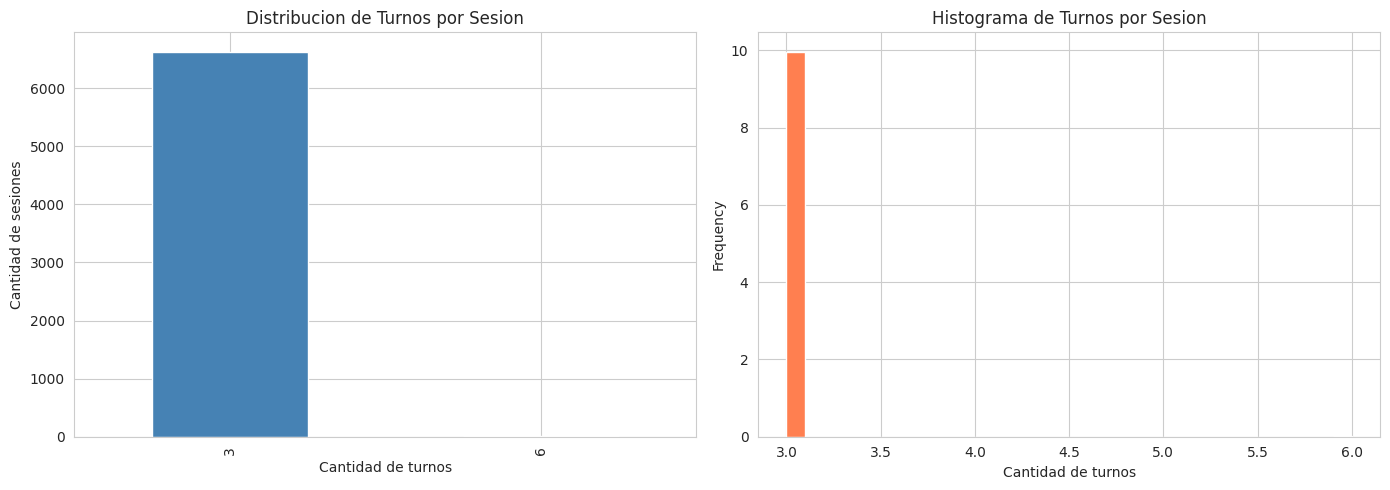

In [5]:
# session_id
n_sessions = df['session_id'].nunique()
print(f'Sesiones unicas: {n_sessions}')
print(f'Turnos promedio por sesion: {df.groupby("session_id").size().mean():.2f}')
print(f'Turnos maximo por sesion: {df.groupby("session_id").size().max()}')
print(f'Turnos minmo por sesion: {df.groupby("session_id").size().min()}')

# Distribucion de turnos por sesion
turns_per_session = df.groupby('session_id').size()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
turns_per_session.value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Distribucion de Turnos por Sesion')
axes[0].set_xlabel('Cantidad de turnos')
axes[0].set_ylabel('Cantidad de sesiones')

turns_per_session.plot(
    kind='hist', bins=30, ax=axes[1], color='coral', edgecolor='white', density=True
)
axes[1].set_title('Histograma de Turnos por Sesion')
axes[1].set_xlabel('Cantidad de turnos')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'turns_per_session.png', bbox_inches='tight')
plt.show()

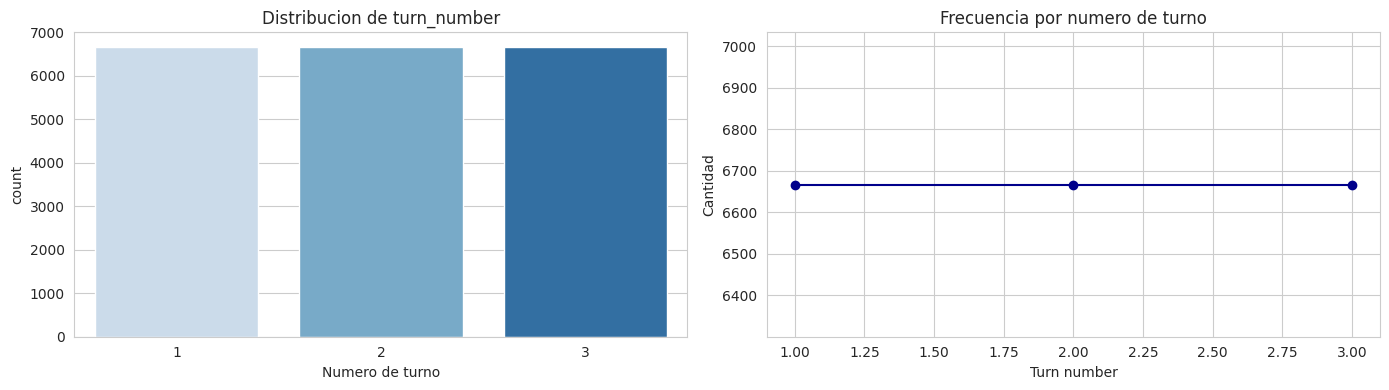

In [6]:
# turn_number
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df, x='turn_number', ax=axes[0], palette='Blues')
axes[0].set_title('Distribucion de turn_number')
axes[0].set_xlabel('Numero de turno')

df['turn_number'].value_counts().sort_index().plot(
    kind='line', marker='o', ax=axes[1], color='darkblue'
)
axes[1].set_title('Frecuencia por numero de turno')
axes[1].set_xlabel('Turn number')
axes[1].set_ylabel('Cantidad')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'turn_number_distribution.png', bbox_inches='tight')
plt.show()

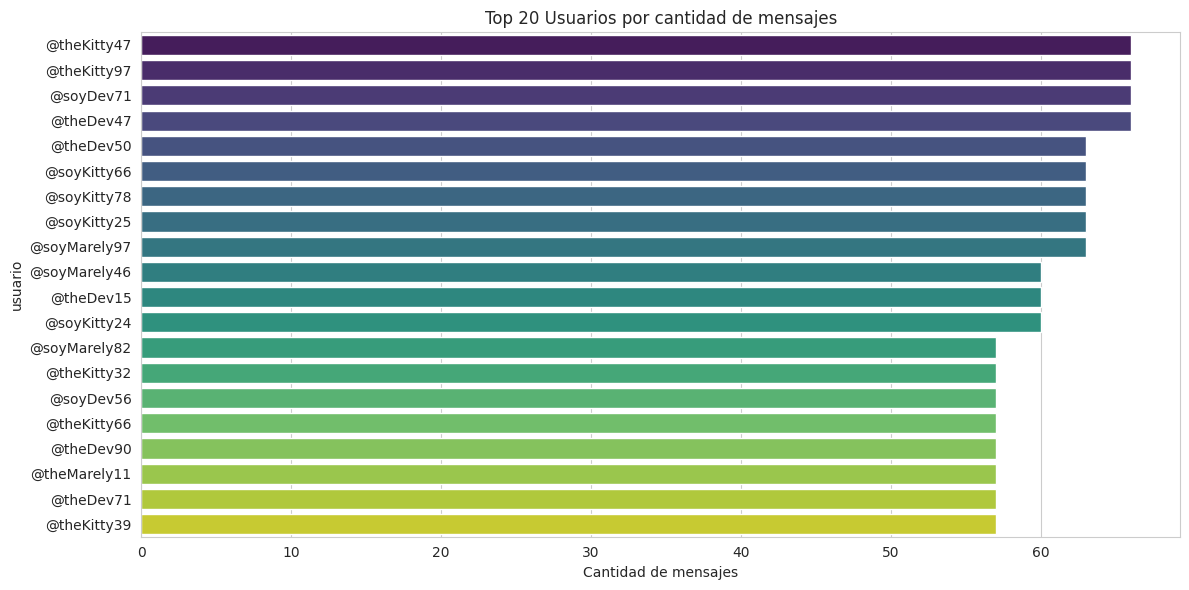

Total de usuarios unicos: 540


In [7]:
# usuario (top 20)
top_usuarios = df['usuario'].value_counts().head(20)
plt.figure(figsize=(12, 6))
sns.barplot(y=top_usuarios.index, x=top_usuarios.values, palette='viridis')
plt.title('Top 20 Usuarios por cantidad de mensajes')
plt.xlabel('Cantidad de mensajes')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'top_usuarios.png', bbox_inches='tight')
plt.show()

print(f'Total de usuarios unicos: {df["usuario"].nunique()}')

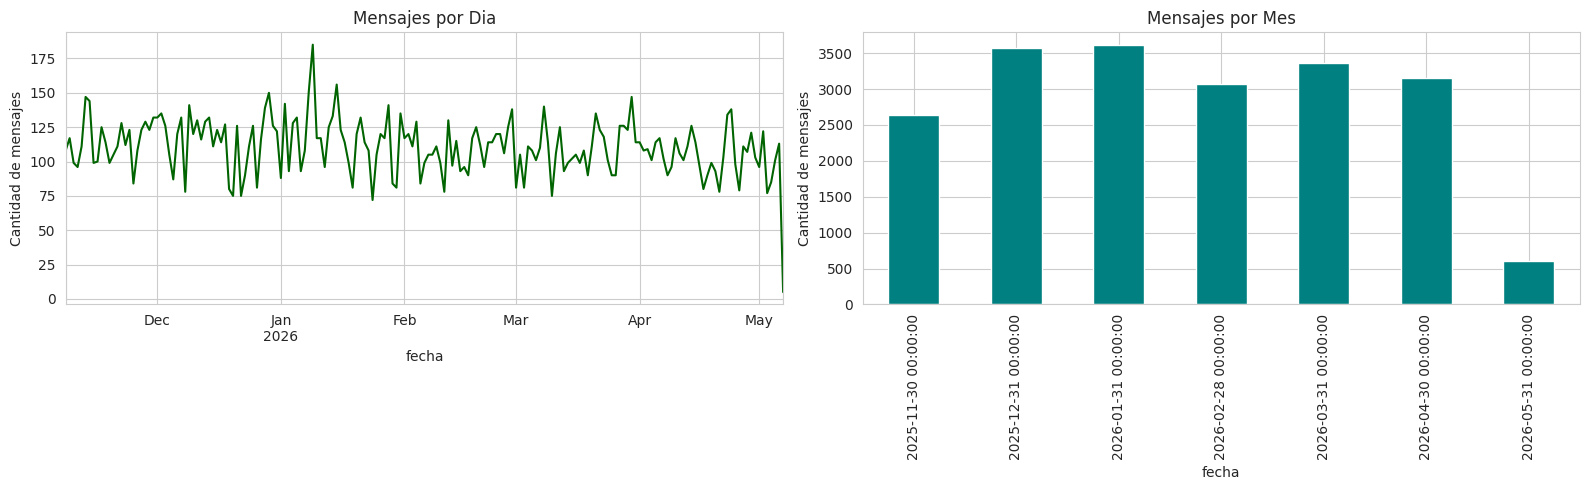

Rango temporal: 2025-11-08 00:58:48 a 2026-05-07 00:52:07


In [8]:
# fecha — linea temporal
df['fecha'] = pd.to_datetime(df['fecha'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mensajes por dia
df.set_index('fecha').resample('D').size().plot(ax=axes[0], color='darkgreen', linewidth=1.5)
axes[0].set_title('Mensajes por Dia')
axes[0].set_ylabel('Cantidad de mensajes')

# Mensajes por mes
df.set_index('fecha').resample('ME').size().plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Mensajes por Mes')
axes[1].set_ylabel('Cantidad de mensajes')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'temporal_distribution.png', bbox_inches='tight')
plt.show()

print(f'Rango temporal: {df["fecha"].min()} a {df["fecha"].max()}')

### 3.2 Variables de texto

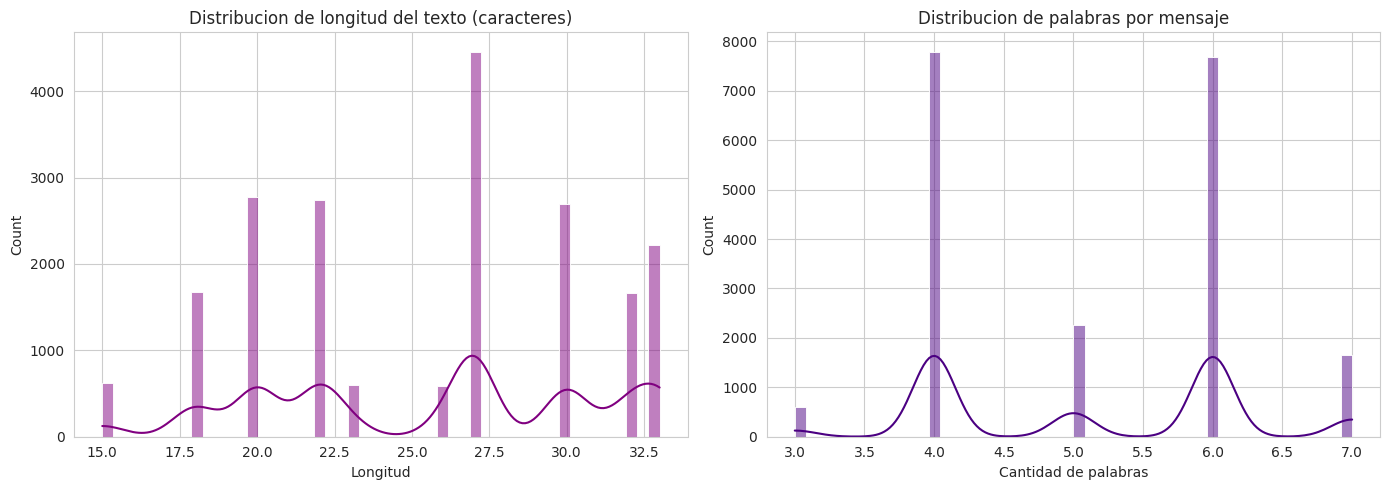

Estadisticas de longitud del texto:
count    20001.000000
mean        25.559772
std          5.209073
min         15.000000
25%         20.000000
50%         27.000000
75%         30.000000
max         33.000000

Estadisticas de cantidad de palabras:
count    20001.000000
mean         5.100795
std          1.101653
min          3.000000
25%          4.000000
50%          5.000000
75%          6.000000
max          7.000000

Texto vacio (texto_vacio=True): 0 registros


In [9]:
# texto_clean — estadisticas de longitud
df['text_length'] = df['texto_clean'].str.len()
df['word_count'] = df['texto_clean'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['text_length'], bins=50, ax=axes[0], color='purple', kde=True)
axes[0].set_title('Distribucion de longitud del texto (caracteres)')
axes[0].set_xlabel('Longitud')

sns.histplot(df['word_count'], bins=50, ax=axes[1], color='indigo', kde=True)
axes[1].set_title('Distribucion de palabras por mensaje')
axes[1].set_xlabel('Cantidad de palabras')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'text_length_distribution.png', bbox_inches='tight')
plt.show()

print('Estadisticas de longitud del texto:')
print(df['text_length'].describe().to_string())
print('\nEstadisticas de cantidad de palabras:')
print(df['word_count'].describe().to_string())
print(f'\nTexto vacio (texto_vacio=True): {df["texto_vacio"].sum()} registros')

In [10]:
# texto_vacio
print(f'Texto vacio: {df["texto_vacio"].value_counts().to_dict()}')
print(f'100% de los textos tienen contenido (segun documentacion)')

Texto vacio: {False: 20001}
100% de los textos tienen contenido (segun documentacion)


### 3.3 Variables de negocio y targets

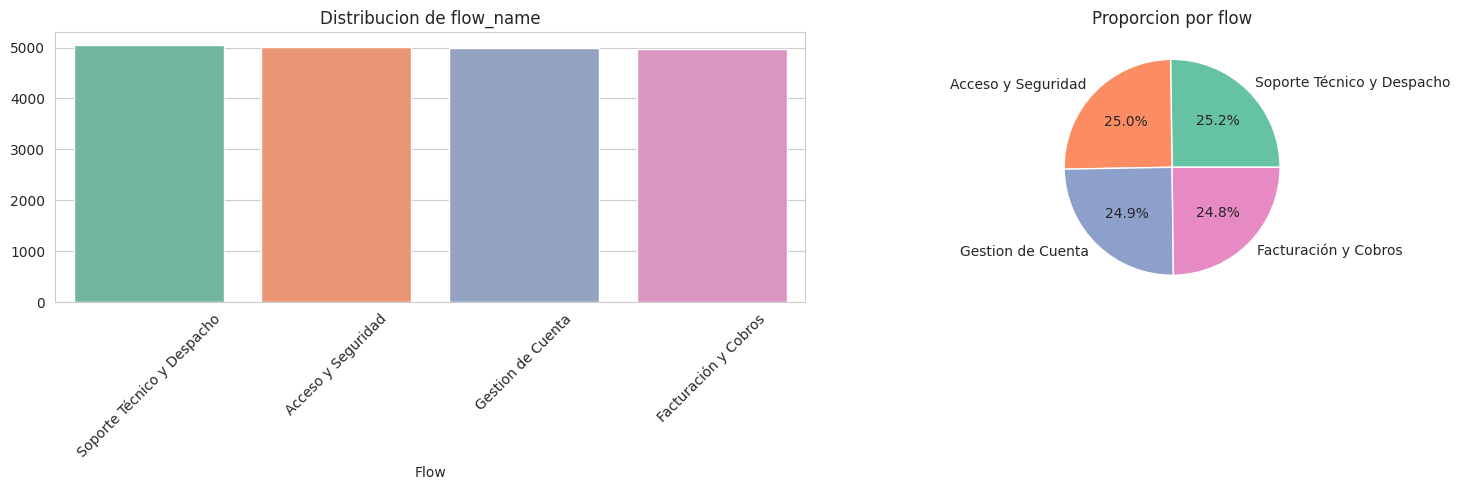

flow_name
Soporte Técnico y Despacho    5046
Acceso y Seguridad            5010
Gestion de Cuenta             4983
Facturación y Cobros          4962
Name: count, dtype: int64


In [11]:
# flow_name
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

flow_counts = df['flow_name'].value_counts()
sns.barplot(x=flow_counts.index, y=flow_counts.values, ax=axes[0], palette='Set2')
axes[0].set_title('Distribucion de flow_name')
axes[0].set_xlabel('Flow')
axes[0].tick_params(axis='x', rotation=45)

flow_counts.plot(kind='pie', autopct='%1.1f%%', ax=axes[1], colors=sns.color_palette('Set2'))
axes[1].set_title('Proporcion por flow')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'flow_name_distribution.png', bbox_inches='tight')
plt.show()

print(flow_counts)

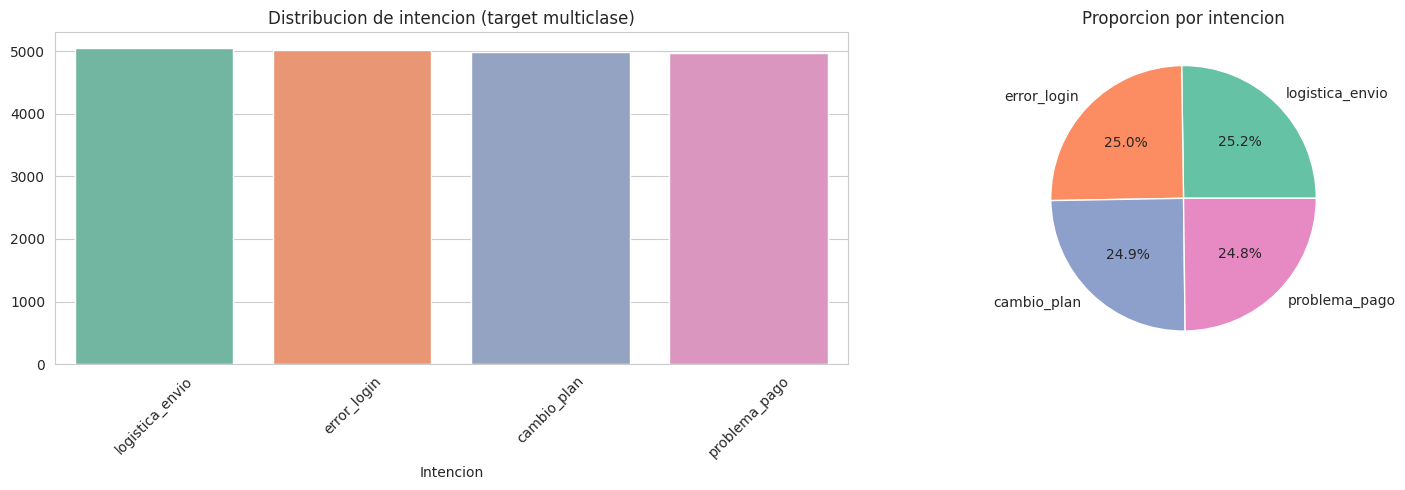

intencion
logistica_envio    5046
error_login        5010
cambio_plan        4983
problema_pago      4962
Name: count, dtype: int64

Balance: 0.983 (min/max)


In [12]:
# intencion — target multiclase
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

intencion_counts = df['intencion'].value_counts()
sns.barplot(x=intencion_counts.index, y=intencion_counts.values, ax=axes[0], palette='Set2')
axes[0].set_title('Distribucion de intencion (target multiclase)')
axes[0].set_xlabel('Intencion')
axes[0].tick_params(axis='x', rotation=45)

intencion_counts.plot(kind='pie', autopct='%1.1f%%', ax=axes[1], colors=sns.color_palette('Set2'))
axes[1].set_title('Proporcion por intencion')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'intencion_distribution.png', bbox_inches='tight')
plt.show()

print(intencion_counts)
print(f'\nBalance: {intencion_counts.min()/intencion_counts.max():.3f} (min/max)')

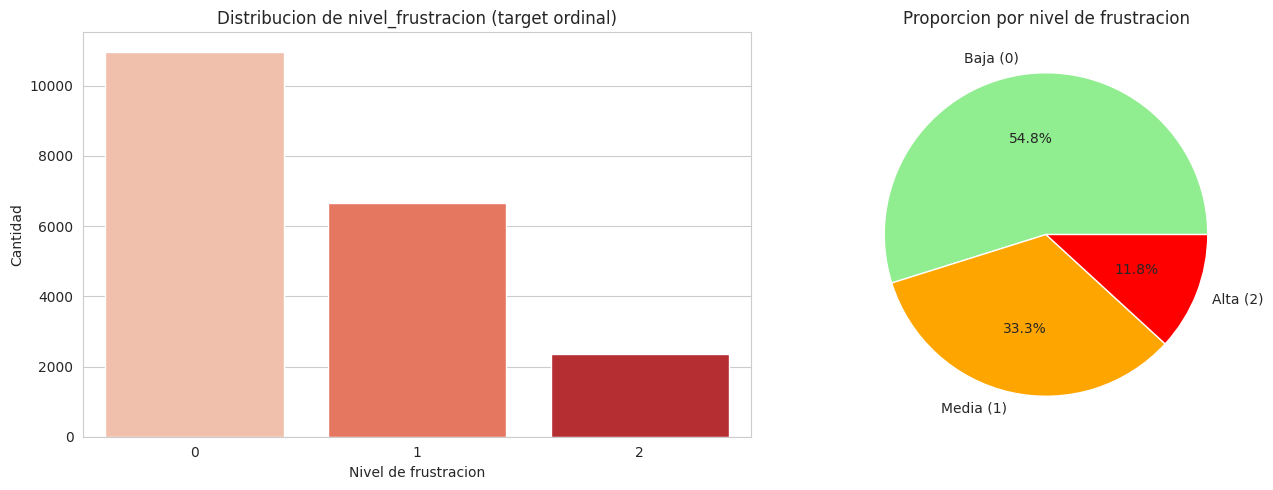

Distribucion de frustracion:
  Nivel 0:  10970 ( 54.8%)
  Nivel 1:   6667 ( 33.3%)
  Nivel 2:   2364 ( 11.8%)


In [13]:
# nivel_frustracion — target ordinal (0/1/2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

frustracion_counts = df['nivel_frustracion'].value_counts().sort_index()
sns.barplot(x=frustracion_counts.index, y=frustracion_counts.values, ax=axes[0], palette='Reds')
axes[0].set_title('Distribucion de nivel_frustracion (target ordinal)')
axes[0].set_xlabel('Nivel de frustracion')
axes[0].set_ylabel('Cantidad')

frustracion_counts.plot(kind='pie', autopct='%1.1f%%', ax=axes[1], 
                       colors=['lightgreen', 'orange', 'red'], labels=['Baja (0)', 'Media (1)', 'Alta (2)'])
axes[1].set_title('Proporcion por nivel de frustracion')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'frustracion_distribution.png', bbox_inches='tight')
plt.show()

print('Distribucion de frustracion:')
for k, v in frustracion_counts.items():
    print(f'  Nivel {k}: {v:>6} ({v/len(df)*100:>5.1f}%)')

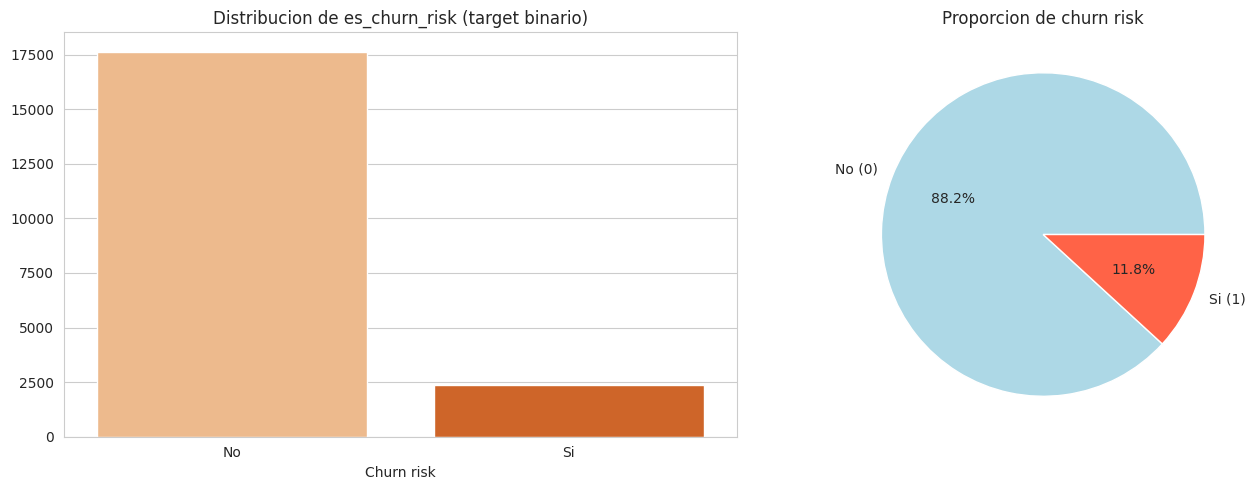

Churn risk = 1: 2364 (11.8%)
Churn risk = 0: 17637 (88.2%)


In [14]:
# es_churn_risk — target binario desbalanceado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

churn_counts = df['es_churn_risk'].value_counts().sort_index()
sns.barplot(x=churn_counts.index, y=churn_counts.values, ax=axes[0], palette='Oranges')
axes[0].set_title('Distribucion de es_churn_risk (target binario)')
axes[0].set_xlabel('Churn risk')
axes[0].set_xticklabels(['No', 'Si'])

churn_counts.plot(kind='pie', autopct='%1.1f%%', ax=axes[1], 
                  colors=['lightblue', 'tomato'], labels=['No (0)', 'Si (1)'])
axes[1].set_title('Proporcion de churn risk')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'churn_distribution.png', bbox_inches='tight')
plt.show()

print(f'Churn risk = 1: {churn_counts[1]} ({churn_counts[1]/len(df)*100:.1f}%)')
print(f'Churn risk = 0: {churn_counts[0]} ({churn_counts[0]/len(df)*100:.1f}%)')

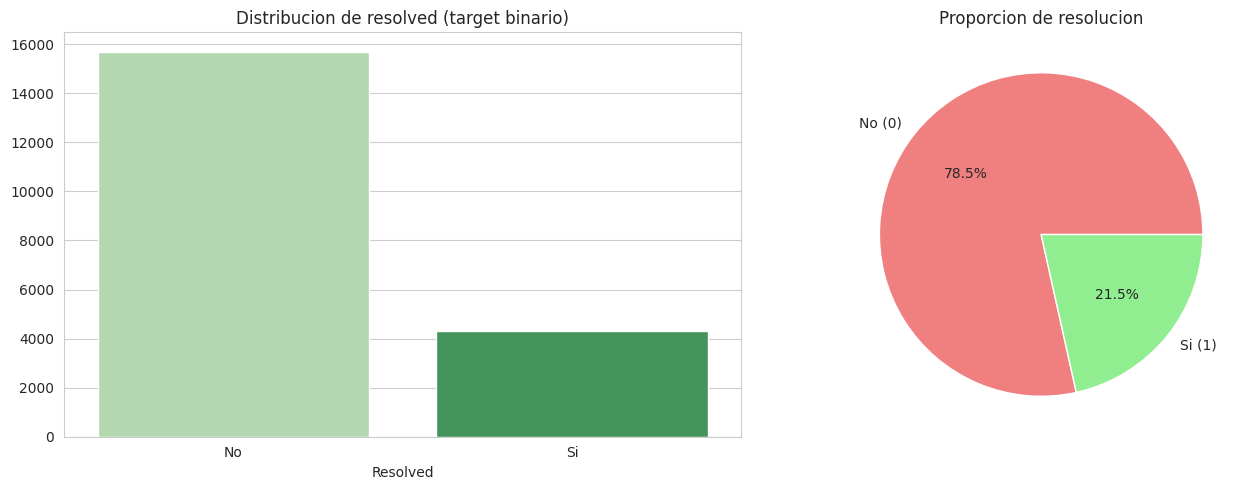

Resolved = 1: 4303 (21.5%)
Resolved = 0: 15698 (78.5%)


In [15]:
# resolved — target binario
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

resolved_counts = df['resolved'].value_counts().sort_index()
sns.barplot(x=resolved_counts.index, y=resolved_counts.values, ax=axes[0], palette='Greens')
axes[0].set_title('Distribucion de resolved (target binario)')
axes[0].set_xlabel('Resolved')
axes[0].set_xticklabels(['No', 'Si'])

resolved_counts.plot(kind='pie', autopct='%1.1f%%', ax=axes[1],
                     colors=['lightcoral', 'lightgreen'], labels=['No (0)', 'Si (1)'])
axes[1].set_title('Proporcion de resolucion')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'resolved_distribution.png', bbox_inches='tight')
plt.show()

print(f'Resolved = 1: {resolved_counts[1]} ({resolved_counts[1]/len(df)*100:.1f}%)')
print(f'Resolved = 0: {resolved_counts[0]} ({resolved_counts[0]/len(df)*100:.1f}%)')

In [16]:
# idioma
idioma_counts = df['idioma'].value_counts()
print(f'Distribucion de idioma:\n{idioma_counts}')

Distribucion de idioma:
idioma
es    20001
Name: count, dtype: int64


---
## 4. ANALISIS MULTIVARIADO

### 4.1 Correlacion entre targets

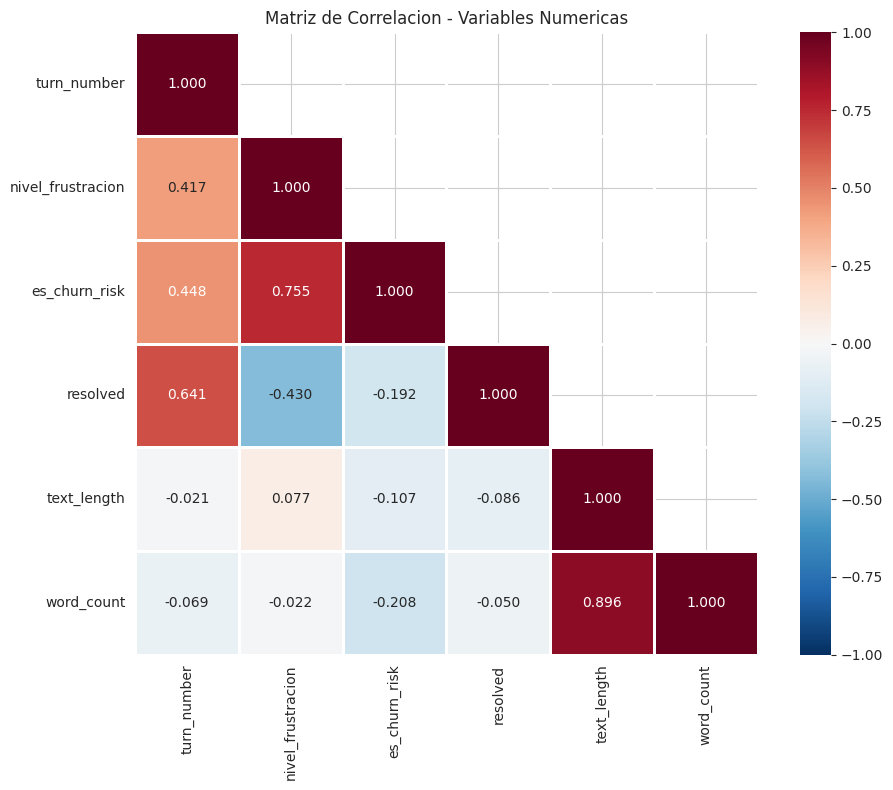

In [17]:
# Matriz de correlacion entre variables numericas
numeric_cols = ['turn_number', 'nivel_frustracion', 'es_churn_risk', 'resolved', 'text_length', 'word_count']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', 
            vmin=-1, vmax=1, center=0, square=True, linewidths=1)
plt.title('Matriz de Correlacion - Variables Numericas')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'correlation_matrix.png', bbox_inches='tight')
plt.show()

Tasa de churn por nivel de frustracion:
es_churn_risk        0    1
nivel_frustracion          
0                  1.0  0.0
1                  1.0  0.0
2                  0.0  1.0


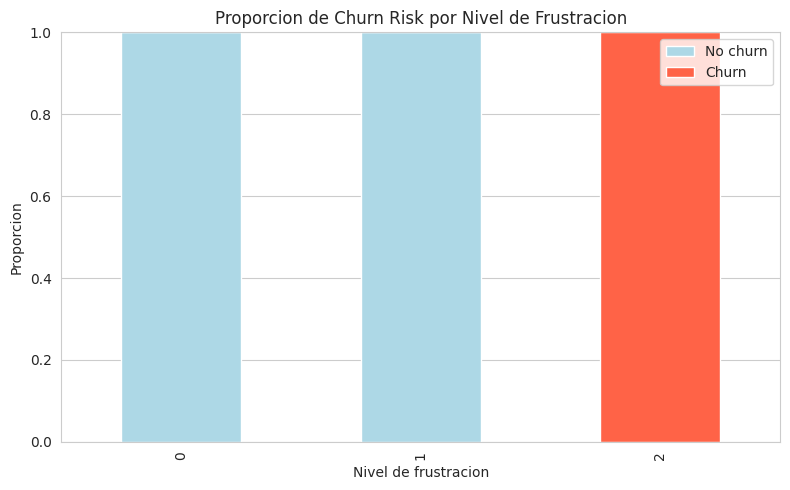

In [18]:
# Relacion frustracion vs churn
ct_frust_churn = pd.crosstab(df['nivel_frustracion'], df['es_churn_risk'], 
                             normalize='index')
print('Tasa de churn por nivel de frustracion:')
print(ct_frust_churn)

fig, ax = plt.subplots(figsize=(8, 5))
ct_frust_churn.plot(kind='bar', stacked=True, ax=ax, 
                    color=['lightblue', 'tomato'])
ax.set_title('Proporcion de Churn Risk por Nivel de Frustracion')
ax.set_xlabel('Nivel de frustracion')
ax.set_ylabel('Proporcion')
ax.legend(['No churn', 'Churn'], loc='upper right')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'frustracion_vs_churn.png', bbox_inches='tight')
plt.show()

Tasa de resolucion por nivel de frustracion:
resolved                  0         1
nivel_frustracion                    
0                  0.607748  0.392252
1                  1.000000  0.000000
2                  1.000000  0.000000


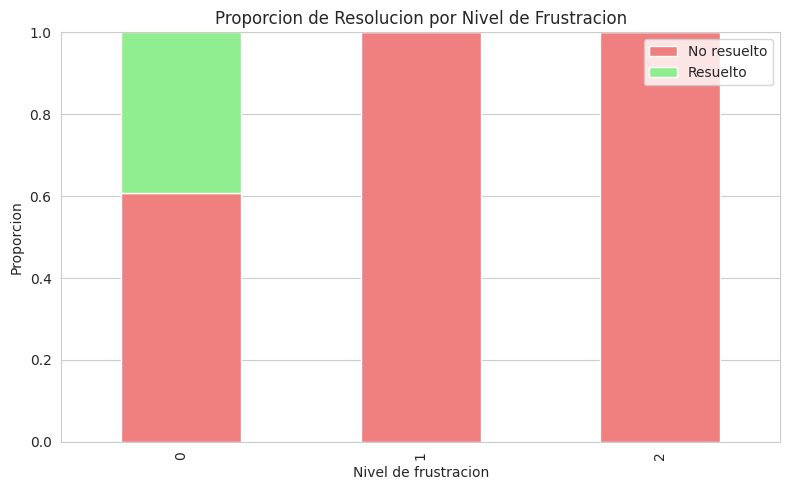

In [19]:
# Relacion frustracion vs resolved
ct_frust_resolved = pd.crosstab(df['nivel_frustracion'], df['resolved'], 
                                normalize='index')
print('Tasa de resolucion por nivel de frustracion:')
print(ct_frust_resolved)

fig, ax = plt.subplots(figsize=(8, 5))
ct_frust_resolved.plot(kind='bar', stacked=True, ax=ax,
                       color=['lightcoral', 'lightgreen'])
ax.set_title('Proporcion de Resolucion por Nivel de Frustracion')
ax.set_xlabel('Nivel de frustracion')
ax.set_ylabel('Proporcion')
ax.legend(['No resuelto', 'Resuelto'], loc='upper right')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'frustracion_vs_resolved.png', bbox_inches='tight')
plt.show()

Distribucion de frustracion por intencion:
nivel_frustracion         0         1         2
intencion                                      
cambio_plan        0.548866  0.333333  0.117801
error_login        0.554092  0.333333  0.112575
logistica_envio    0.548950  0.333333  0.117717
problema_pago      0.541919  0.333333  0.124748


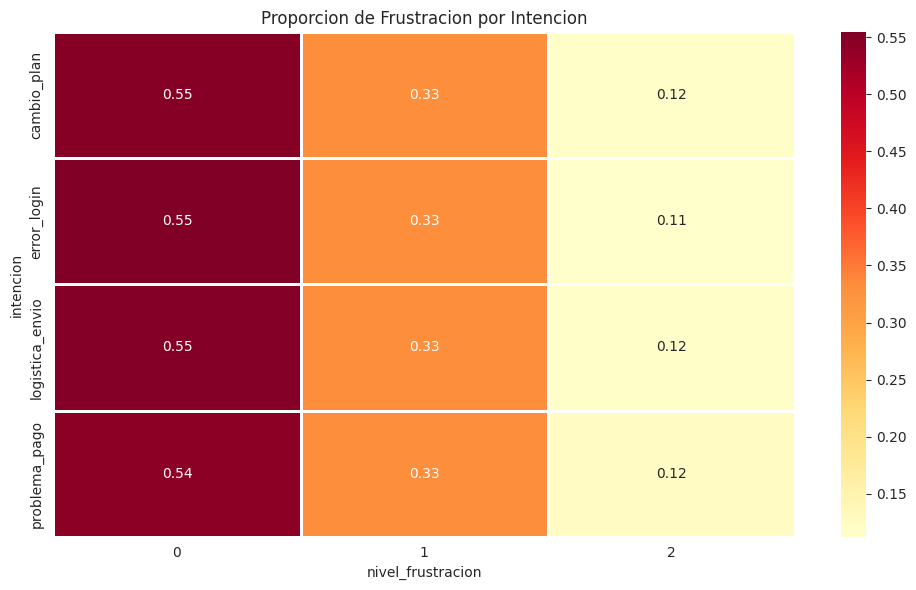

In [20]:
# Relacion intencion vs frustracion
ct_intent_frust = pd.crosstab(df['intencion'], df['nivel_frustracion'], normalize='index')
print('Distribucion de frustracion por intencion:')
print(ct_intent_frust)

plt.figure(figsize=(10, 6))
sns.heatmap(ct_intent_frust, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=1)
plt.title('Proporcion de Frustracion por Intencion')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'intent_vs_frustracion.png', bbox_inches='tight')
plt.show()

In [21]:
# Relacion flow_name vs intencion
print('Relacion flow_name vs intencion (deberia ser 1:1):')
ct_flow_intent = pd.crosstab(df['flow_name'], df['intencion'])
print(ct_flow_intent)

print(f'\nCoincidencia 1:1: {all(ct_flow_intent.sum(axis=1) == ct_flow_intent.max(axis=1))}')

Relacion flow_name vs intencion (deberia ser 1:1):
intencion                   cambio_plan  error_login  logistica_envio  \
flow_name                                                               
Acceso y Seguridad                    0         5010                0   
Facturación y Cobros                  0            0                0   
Gestion de Cuenta                  4983            0                0   
Soporte Técnico y Despacho            0            0             5046   

intencion                   problema_pago  
flow_name                                  
Acceso y Seguridad                      0  
Facturación y Cobros                 4962  
Gestion de Cuenta                       0  
Soporte Técnico y Despacho              0  

Coincidencia 1:1: True


### 4.2 Relaciones con features contextuales

Frustracion promedio por turno:
turn_number
1    0.000000
2    1.000000
3    0.709165
Name: nivel_frustracion, dtype: float64


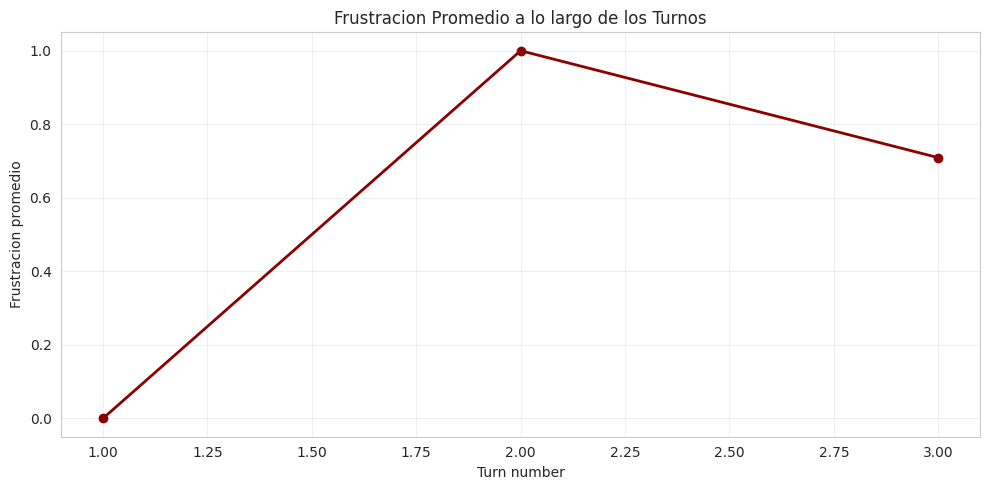

In [22]:
# Frustracion a lo largo de los turnos
frust_by_turn = df.groupby('turn_number')['nivel_frustracion'].mean()
print('Frustracion promedio por turno:')
print(frust_by_turn)

plt.figure(figsize=(10, 5))
frust_by_turn.plot(kind='line', marker='o', color='darkred', linewidth=2)
plt.title('Frustracion Promedio a lo largo de los Turnos')
plt.xlabel('Turn number')
plt.ylabel('Frustracion promedio')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'frustracion_by_turn.png', bbox_inches='tight')
plt.show()

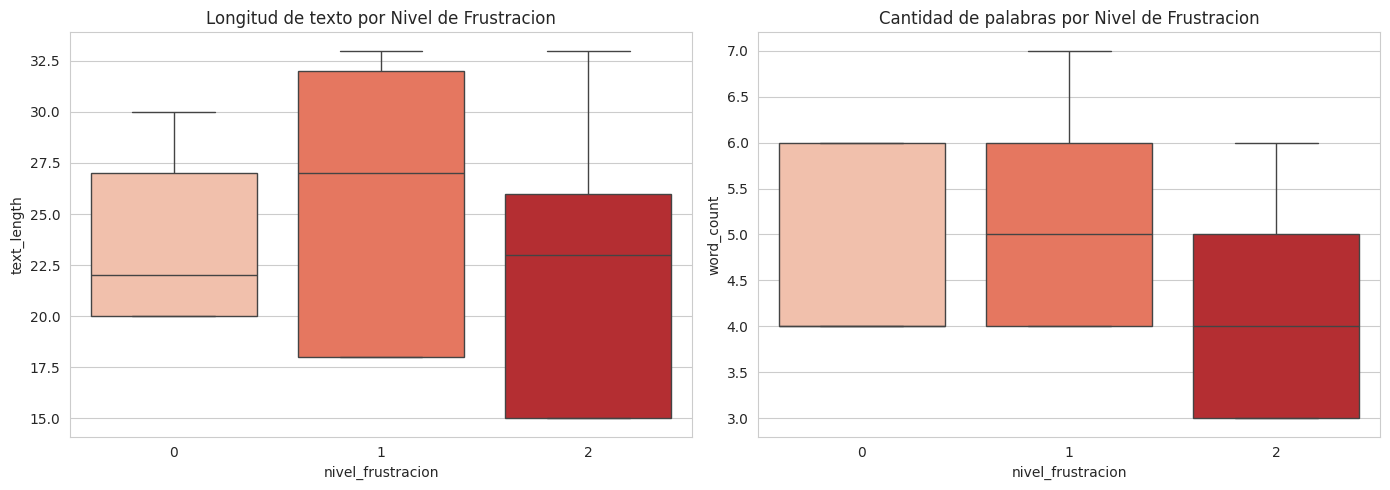

In [23]:
# Longitud de texto por nivel de frustracion
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='nivel_frustracion', y='text_length', palette='Reds')
plt.title('Longitud de texto por Nivel de Frustracion')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='nivel_frustracion', y='word_count', palette='Reds')
plt.title('Cantidad de palabras por Nivel de Frustracion')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'text_length_by_frustracion.png', bbox_inches='tight')
plt.show()

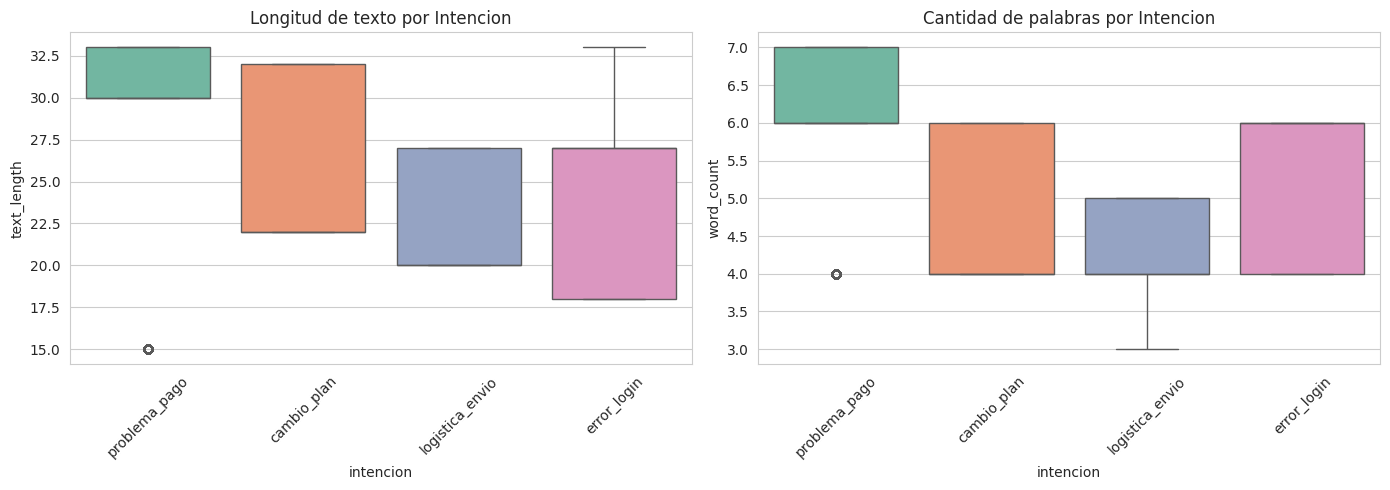

In [24]:
# Longitud de texto por intencion
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='intencion', y='text_length', palette='Set2')
plt.title('Longitud de texto por Intencion')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='intencion', y='word_count', palette='Set2')
plt.title('Cantidad de palabras por Intencion')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'text_length_by_intent.png', bbox_inches='tight')
plt.show()

## 5. ANALISIS DE SESIONES

Exploramos patrones a nivel de sesion (conversacion completa)

In [25]:
# Agregacion por sesion
session_df = df.groupby('session_id').agg({
    'turn_number': 'max',
    'flow_name': 'first',
    'intencion': 'first',
    'nivel_frustracion': 'max',
    'es_churn_risk': 'max',
    'resolved': 'max',
    'usuario': 'first',
    'fecha': 'min',
    'text_length': 'sum',
    'word_count': 'sum'
}).reset_index()

session_df.columns = ['session_id', 'n_turns', 'flow_name', 'intencion', 
                       'max_frustracion', 'churn_risk', 'resolved', 
                       'first_usuario', 'first_fecha', 'total_text_length', 'total_word_count']

print(f'Sesiones totales: {len(session_df)}')
session_df.head()

Sesiones totales: 6648


,session_id,n_turns,flow_name,intencion,max_frustracion,churn_risk,resolved,first_usuario,first_fecha,total_text_length,total_word_count
0,SESS-100088,3,Gestion de Cuenta,cambio_plan,1,0,1,@theDev76,2026-04-12 18:49:47,76,14
1,SESS-100689,3,Soporte Técnico y Despacho,logistica_envio,1,0,1,@theMarely62,2026-04-24 19:05:00,67,13
2,SESS-100709,3,Gestion de Cuenta,cambio_plan,1,0,1,@soyKitty72,2026-01-17 11:27:08,76,14
3,SESS-100747,3,Gestion de Cuenta,cambio_plan,1,0,1,@soyDev30,2025-12-08 06:03:15,76,14
4,SESS-101662,3,Soporte Técnico y Despacho,logistica_envio,1,0,1,@theMarely64,2026-01-01 20:19:21,67,13


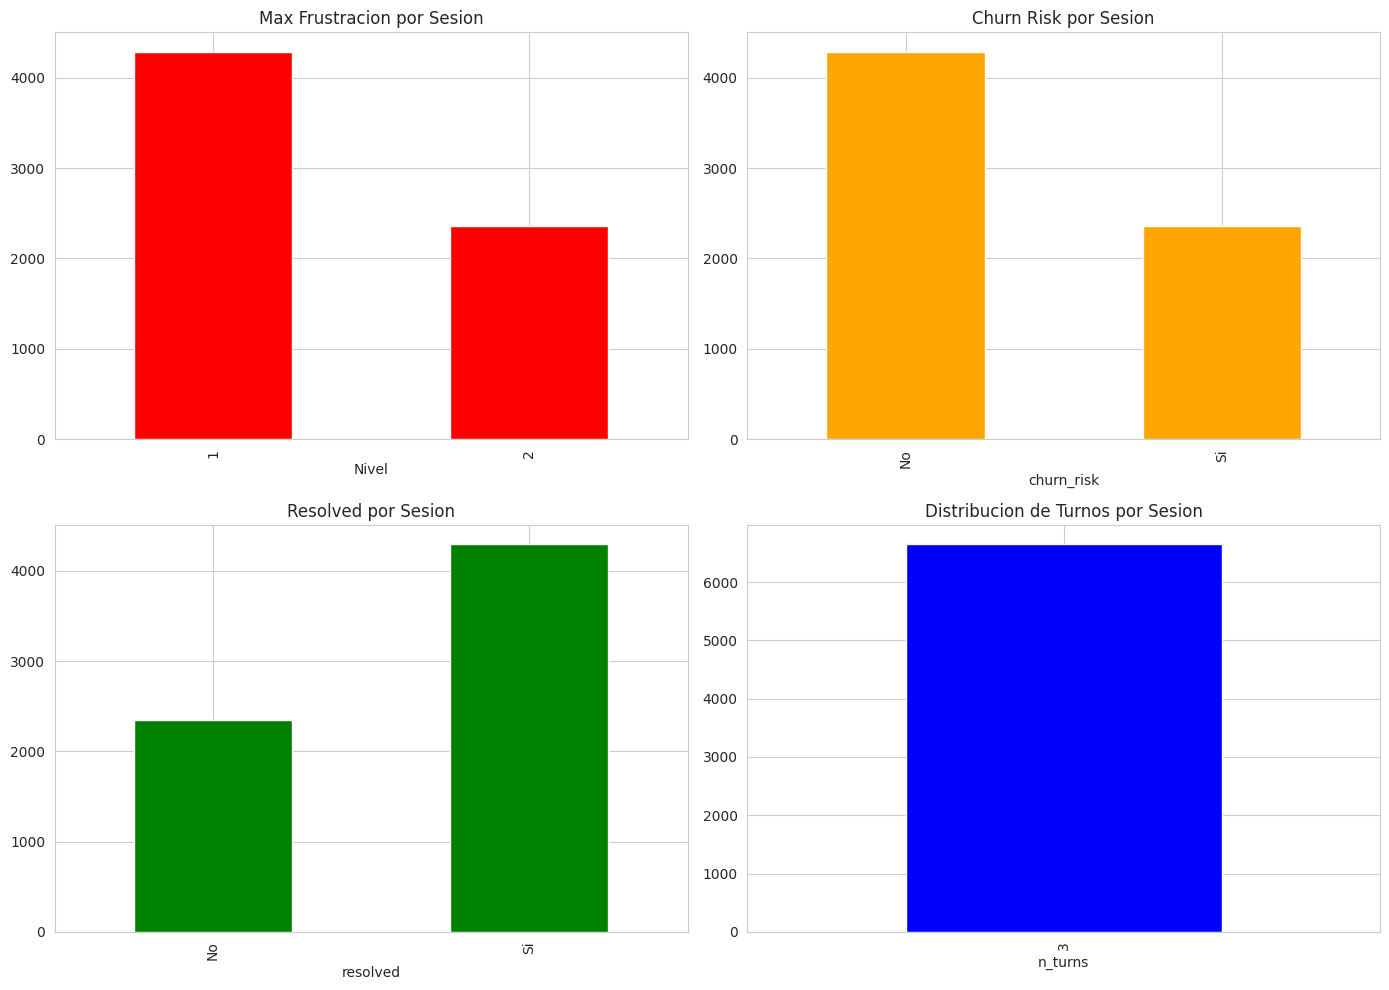

In [26]:
# Distribucion de target a nivel sesion
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Frustracion maxima por sesion
session_df['max_frustracion'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0,0], color='Red')
axes[0,0].set_title('Max Frustracion por Sesion')
axes[0,0].set_xlabel('Nivel')

# Churn por sesion
session_df['churn_risk'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0,1], color='Orange')
axes[0,1].set_title('Churn Risk por Sesion')
axes[0,1].set_xticklabels(['No', 'Si'])

# Resolved por sesion
session_df['resolved'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1,0], color='Green')
axes[1,0].set_title('Resolved por Sesion')
axes[1,0].set_xticklabels(['No', 'Si'])

# Turnos por sesion
session_df['n_turns'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1,1], color='Blue')
axes[1,1].set_title('Distribucion de Turnos por Sesion')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'session_targets_distribution.png', bbox_inches='tight')
plt.show()

In [27]:
# Resumen de sesiones por flow
session_flow = session_df.groupby('flow_name').agg({
    'session_id': 'count',
    'churn_risk': 'mean',
    'resolved': 'mean',
    'max_frustracion': 'mean',
    'n_turns': 'mean'
}).round(3)

session_flow.columns = ['sesiones', 'tasa_churn', 'tasa_resolucion', 'frustracion_promedio', 'turnos_promedio']
print('Metricas por flow:')
session_flow

Metricas por flow:


,sesiones,tasa_churn,tasa_resolucion,frustracion_promedio,turnos_promedio
flow_name,,,,,
Acceso y Seguridad,1667,0.338,0.663,1.338,3.0
Facturación y Cobros,1650,0.374,0.627,1.374,3.0
Gestion de Cuenta,1656,0.353,0.649,1.353,3.0
Soporte Técnico y Despacho,1675,0.356,0.646,1.356,3.0


## 6. ANALISIS DE TEXTO EXPLORATORIO

Exploramos las palabras mas frecuentes por target para entender el contenido

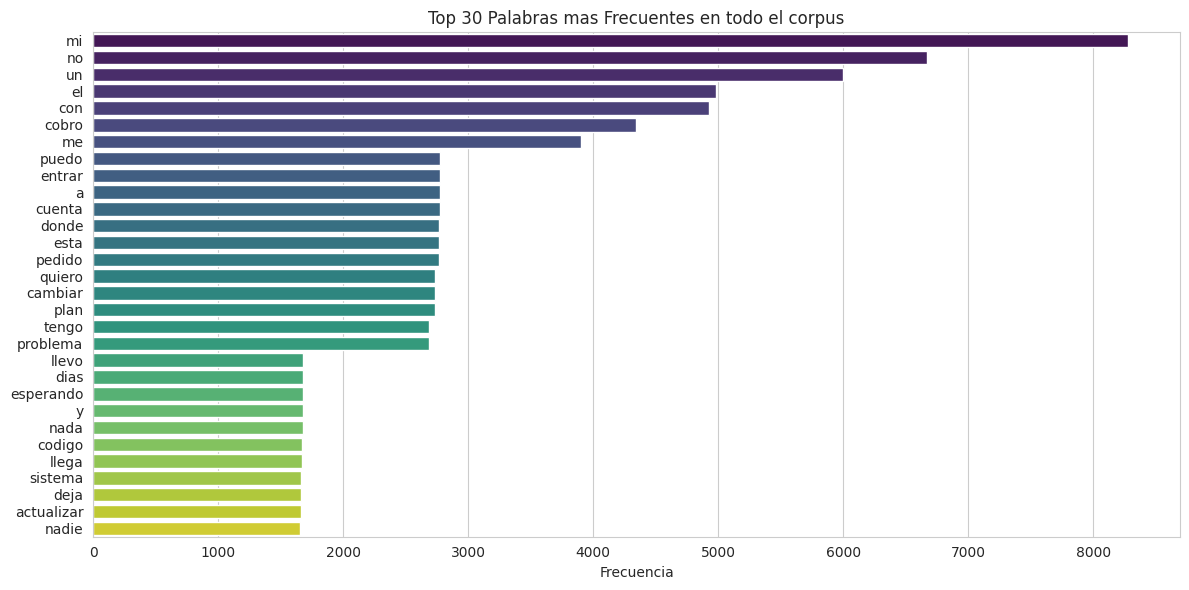

In [28]:
from collections import Counter

# Palabras mas frecuentes general
all_words = ' '.join(df['texto_clean']).split()
word_freq = Counter(all_words).most_common(30)

words, counts = zip(*word_freq)
plt.figure(figsize=(12, 6))
sns.barplot(y=list(words), x=list(counts), palette='viridis')
plt.title('Top 30 Palabras mas Frecuentes en todo el corpus')
plt.xlabel('Frecuencia')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'top_words_general.png', bbox_inches='tight')
plt.show()

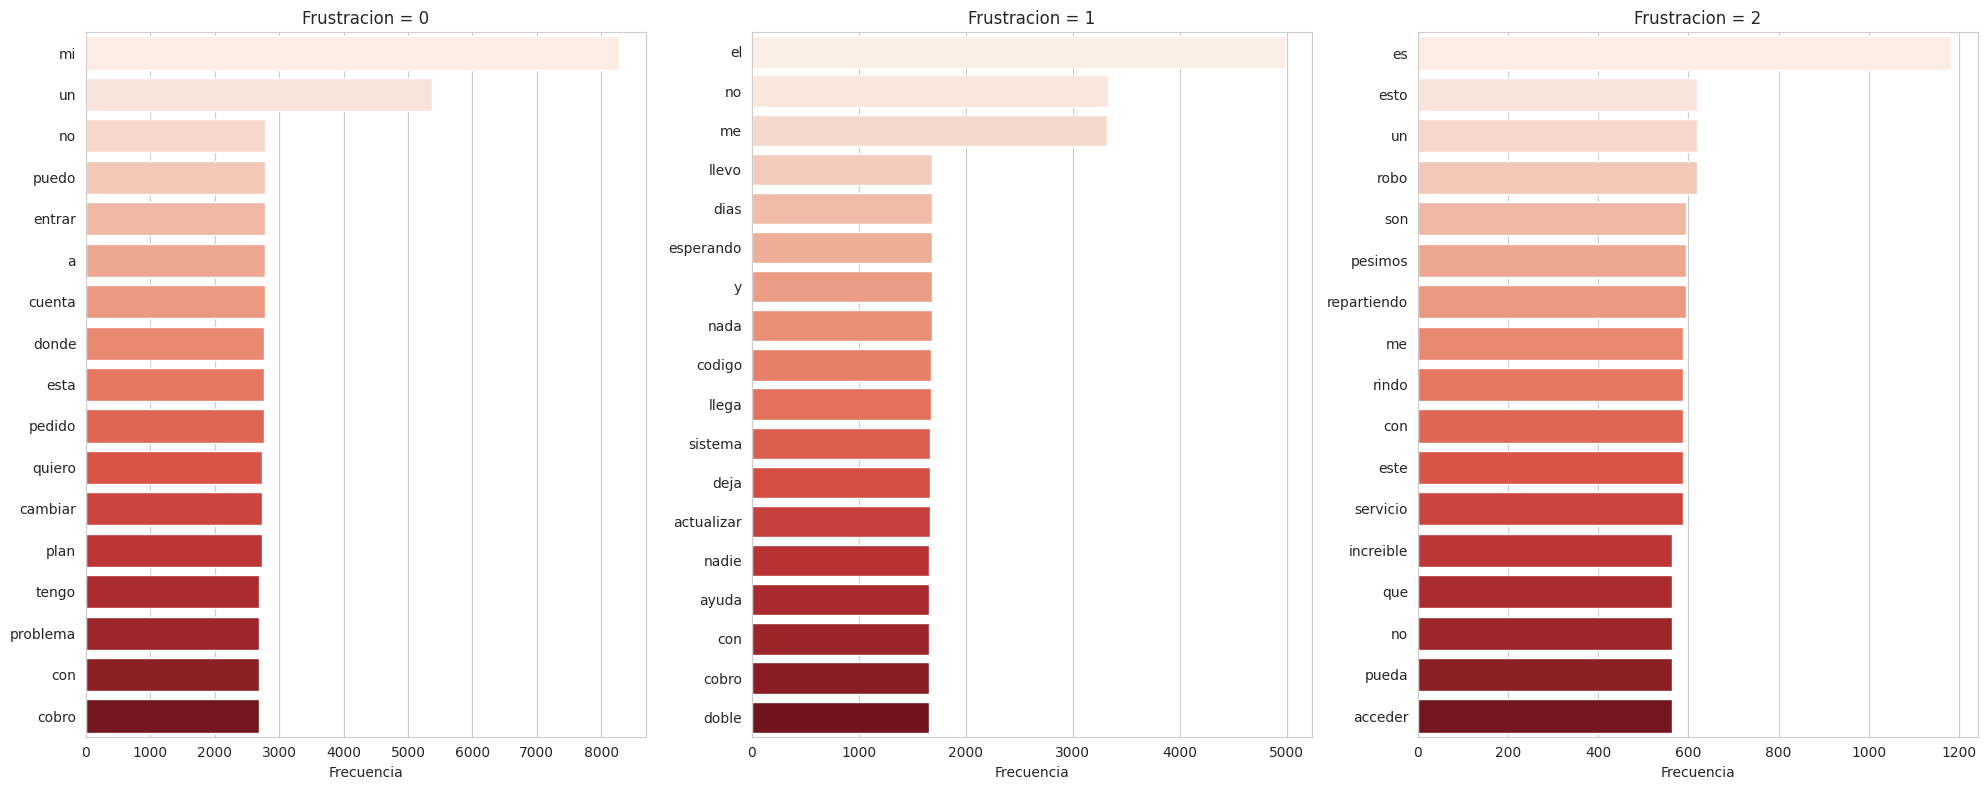

In [29]:
# Palabras mas frecuentes por nivel de frustracion
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for i, nivel in enumerate([0, 1, 2]):
    words_nivel = ' '.join(df[df['nivel_frustracion'] == nivel]['texto_clean']).split()
    freq_nivel = Counter(words_nivel).most_common(20)
    words, counts = zip(*freq_nivel)
    
    sns.barplot(y=list(words), x=list(counts), ax=axes[i], palette='Reds')
    axes[i].set_title(f'Frustracion = {nivel}')
    axes[i].set_xlabel('Frecuencia')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'top_words_by_frustracion.png', bbox_inches='tight')
plt.show()

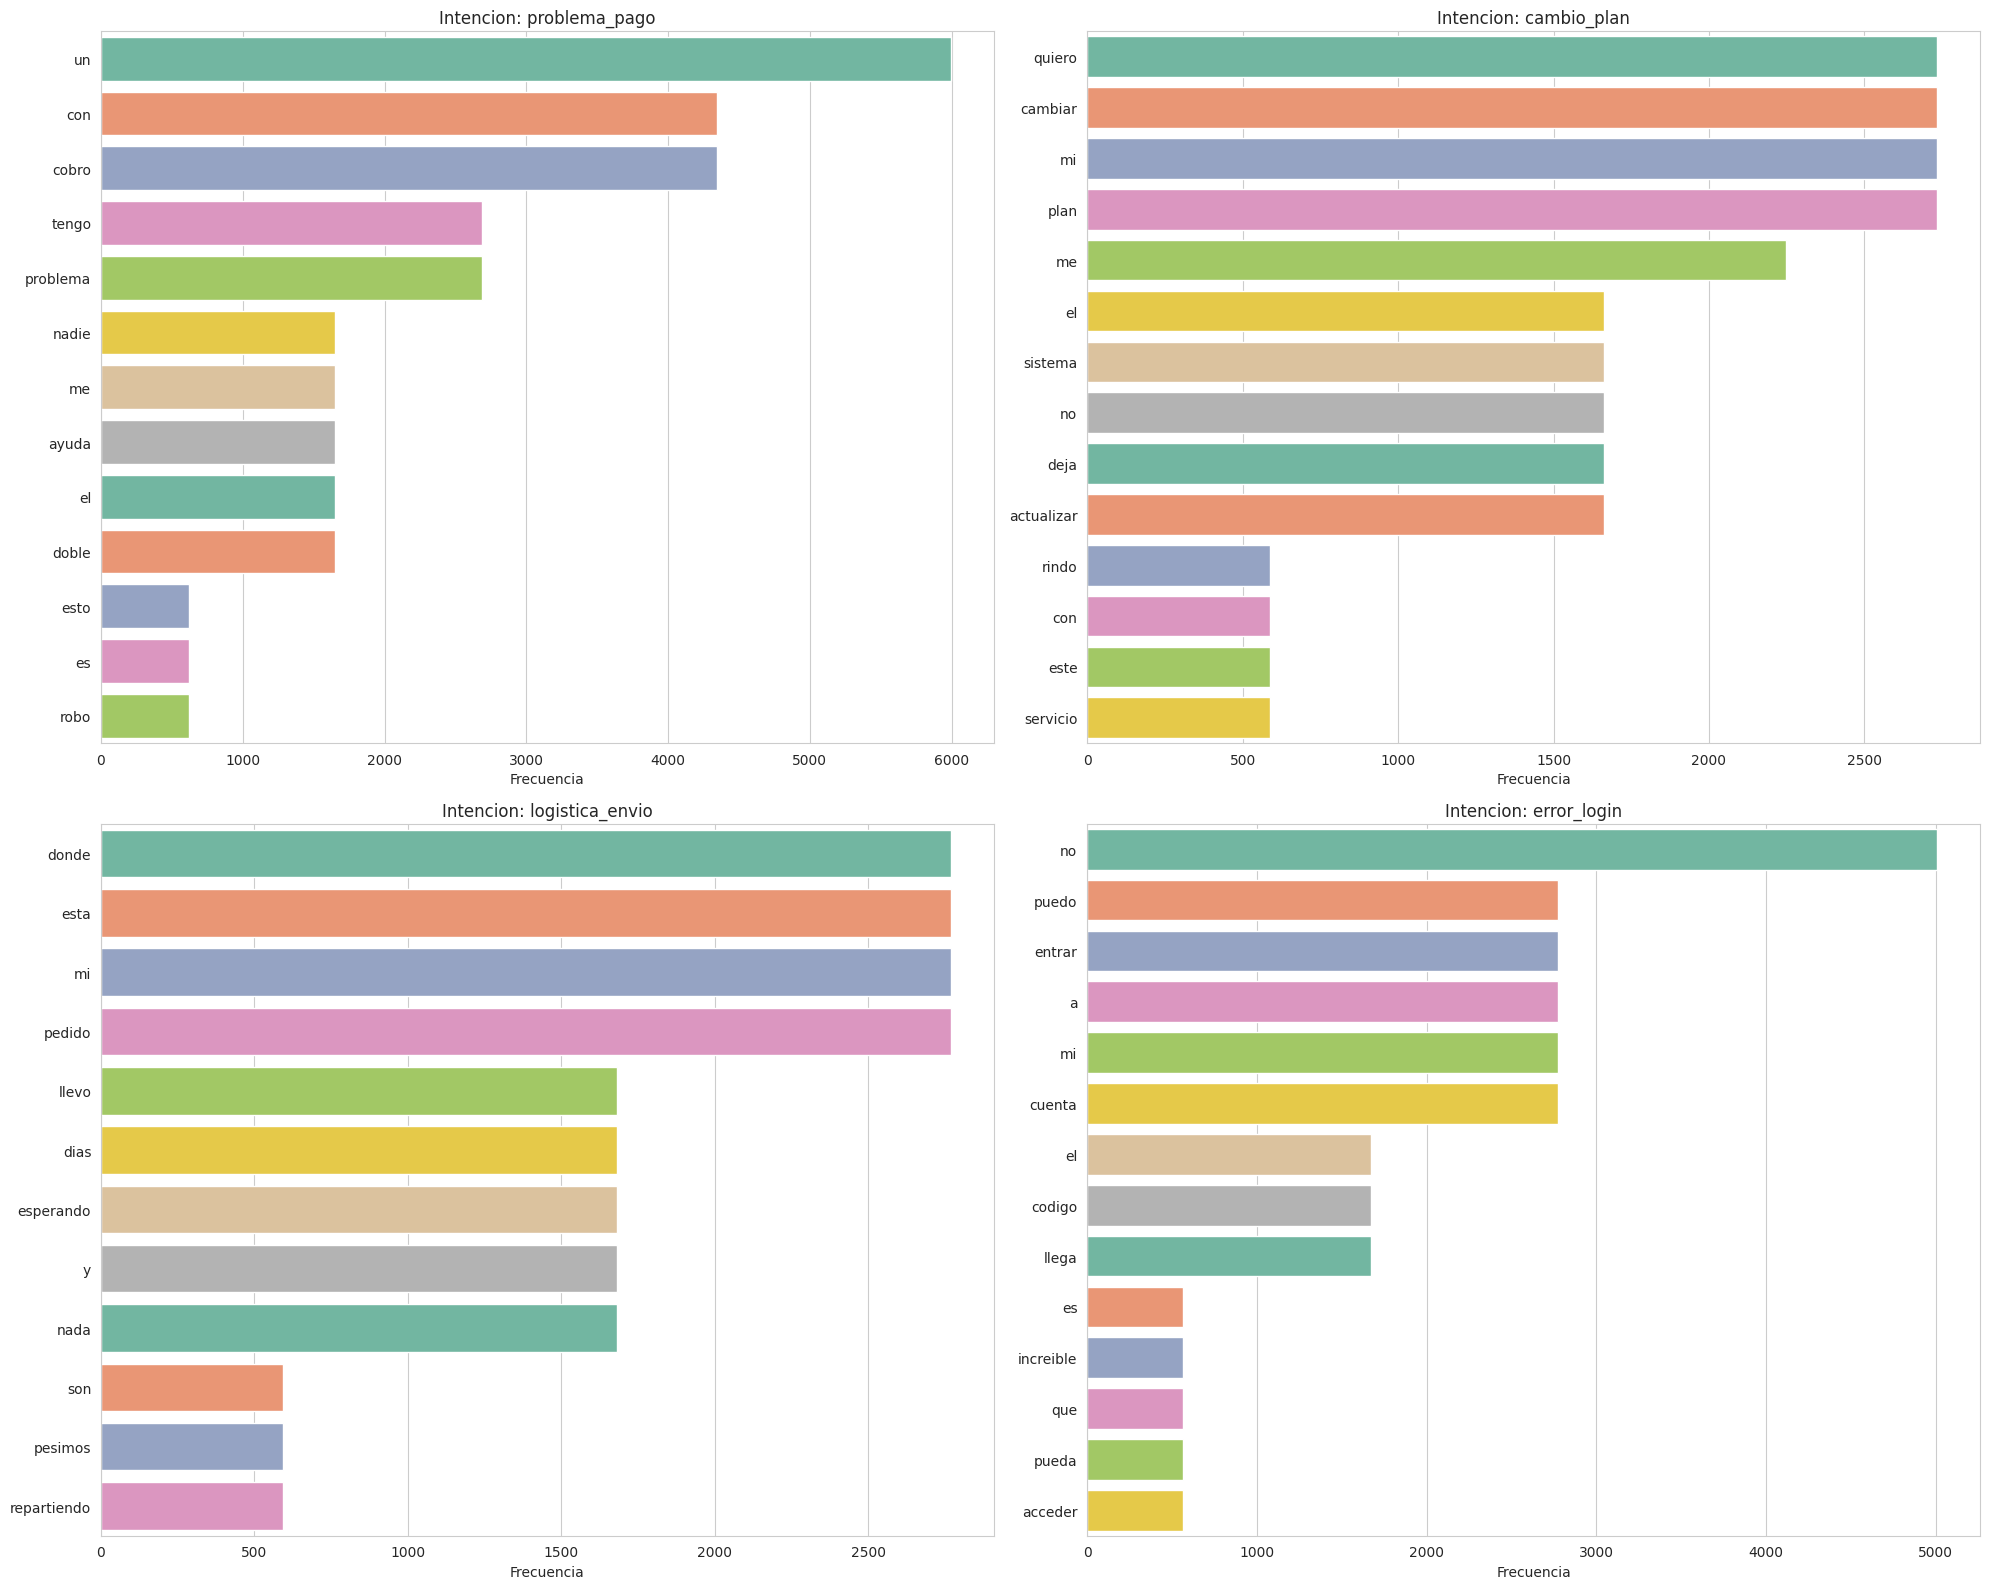

In [30]:
# Palabras mas frecuentes por intencion
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for i, intencion in enumerate(df['intencion'].unique()):
    words_int = ' '.join(df[df['intencion'] == intencion]['texto_clean']).split()
    freq_int = Counter(words_int).most_common(20)
    words, counts = zip(*freq_int)
    
    sns.barplot(y=list(words), x=list(counts), ax=axes[i], palette='Set2')
    axes[i].set_title(f'Intencion: {intencion}')
    axes[i].set_xlabel('Frecuencia')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'top_words_by_intent.png', bbox_inches='tight')
plt.show()

## 7. VERIFICACION DE CALIDAD

Validamos lo que dice la documentacion sobre el dataset

In [31]:
# 1. Valores nulos (deberian ser 0)
nulls = df.isnull().sum()
print('Valores nulos por columna:')
print(nulls[nulls > 0] if nulls.any() else '  Ningun valor nulo encontrado. OK.')

# 2. texto_vacio (deberia ser False en todos)
print(f'\nRegistros con texto_vacio=True: {df["texto_vacio"].sum()}')

# 3. Valores fuera de rango en frustracion
frust_range_ok = df['nivel_frustracion'].isin([0, 1, 2]).all()
print(f'\nnivel_frustracion en rango [0,1,2]: {frust_range_ok}')

# 4. Valores fuera de rango en churn y resolved
print(f'es_churn_risk binario: {df["es_churn_risk"].isin([0, 1]).all()}')
print(f'resolved binario: {df["resolved"].isin([0, 1]).all()}')

# 5. Flow -> Intent mapping (1:1)
flow_intent_map = df.groupby('flow_name')['intencion'].nunique()
print(f'\nRelacion flow_name -> intencion (debe ser 1:1):')
print(flow_intent_map)

# 6. Misma cantidad frustracion=2 y churn=1
f2 = (df['nivel_frustracion'] == 2).sum()
c1 = (df['es_churn_risk'] == 1).sum()
print(f'\nFrustracion=2: {f2}')
print(f'Churn=1: {c1}')
print(f'Coinciden: {f2 == c1}')

Valores nulos por columna:
  Ningun valor nulo encontrado. OK.

Registros con texto_vacio=True: 0

nivel_frustracion en rango [0,1,2]: True
es_churn_risk binario: True
resolved binario: True

Relacion flow_name -> intencion (debe ser 1:1):
flow_name
Acceso y Seguridad            1
Facturación y Cobros          1
Gestion de Cuenta             1
Soporte Técnico y Despacho    1
Name: intencion, dtype: int64

Frustracion=2: 2364
Churn=1: 2364
Coinciden: True


In [32]:
# Resumen de correlacion frustracion-churn
print('Analisis de correlacion frustracion vs churn:')
ct = pd.crosstab(df['nivel_frustracion'], df['es_churn_risk'])
print(ct)
print()
print(f'De {f2} registros con frustracion=2:')
f2_churn1 = ((df['nivel_frustracion'] == 2) & (df['es_churn_risk'] == 1)).sum()
print(f'  - Con churn=1: {f2_churn1} ({f2_churn1/f2*100:.1f}%)')
print(f'  - Con churn=0: {f2 - f2_churn1} ({(f2 - f2_churn1)/f2*100:.1f}%)')

Analisis de correlacion frustracion vs churn:
es_churn_risk          0     1
nivel_frustracion             
0                  10970     0
1                   6667     0
2                      0  2364

De 2364 registros con frustracion=2:
  - Con churn=1: 2364 (100.0%)
  - Con churn=0: 0 (0.0%)


## 8. RESUMEN DE HALLAZGOS

Completar despues de ejecutar el notebook con los hallazgos observados.

In [33]:
print('========== RESUMEN EJECUTIVO ==========')
print(f'\nDataset:')
print(f'  - {df.shape[0]} filas, {df.shape[1]} columnas')
print(f'  - {df["session_id"].nunique()} sesiones unicas')
print(f'  - Sin valores nulos')
print(f'\nTargets:')
print(f'  - nivel_frustracion: ordinal 3 clases, desbalanceado (clase 2: ~12%)')
print(f'  - intencion: 4 clases balanceadas')
print(f'  - es_churn_risk: binario, desbalanceado (~12% positivo)')
print(f'  - resolved: binario, desbalanceado (~22% positivo)')
print(f'\nCorrelaciones clave:')
print(f'  - frustracion=2 y churn=1: {f2_churn1}/{f2} ({f2_churn1/f2*100:.1f}% de coincidencia)')
print(f'  - flow_name mapea 1:1 con intencion')
print(f'\nSesiones:')
print(f'  - ~3 turnos por sesion en promedio')
print(f'\nTexto:')
print(f'  - Longitud promedio: {df["text_length"].mean():.0f} caracteres')
print(f'  - Promedio de palabras: {df["word_count"].mean():.0f} palabras')

========== RESUMEN EJECUTIVO ==========

Dataset:
  - 20001 filas, 17 columnas
  - 6648 sesiones unicas
  - Sin valores nulos

Targets:
  - nivel_frustracion: ordinal 3 clases, desbalanceado (clase 2: ~12%)
  - intencion: 4 clases balanceadas
  - es_churn_risk: binario, desbalanceado (~12% positivo)
  - resolved: binario, desbalanceado (~22% positivo)

Correlaciones clave:
  - frustracion=2 y churn=1: 2364/2364 (100.0% de coincidencia)
  - flow_name mapea 1:1 con intencion

Sesiones:
  - ~3 turnos por sesion en promedio

Texto:
  - Longitud promedio: 26 caracteres
  - Promedio de palabras: 5 palabras


## 9. Reporte

En: `reports/eda_report.md`